<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<div style="text-align: center;">
  <h1>Dividend Taxation and Top-Income Inequality</h1>
  <h3>HEC Liege</h3>
  <h4><em>Lucas Dubois</em></h4>
</div>

<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = '/Users/lucasdubois/Desktop/MASTERDATA/' 
df = pd.read_csv(path + "MASTER_FINAL.csv")

<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


<div style="text-align: align;">
  <h2> <small>2</small>&nbsp;&nbsp;&nbsp;&nbsp;Descriptive Statistics:</h2>
</div>

<hr style="border:none; border-top:2px dashed #fff; margin:1em 0;">

<div style="text-align: align;">
  <h3> <small>2.1</small>&nbsp;&nbsp;&nbsp;&nbsp;Correlation:</h3>
</div>

In [17]:
inequality_variables = [
    "top10_inc",
    "top1_inc",
    "top10_w",
    "top1_w",
    "gini_disp",
    "gini_mkt",
    "gini_disp_se",
    "gini_mkt_se"
]

interaction_variables = [
    "log_rgdpe",
    "log_pop",
    "log_emp",
    "log_cn",
    "rgdpe_sq",
    "log_rgdpe_sq",
    "hc_ctfp",
    "labsh_irr",
    "cn_ctfp",
    "xr_irr",
    "csh_g_hc",
    "csh_c_hc",
    "rgdpe_ctfp",
    "pop_rgdpe",
    "delta_cn"
]

id_variables = ["Country Name", "Year"]

X = [
    col for col in df.columns
    if col not in inequality_variables + interaction_variables + id_variables
]

In [18]:
corr_matrix = df[X].corr()
corr_matrix_rounded = corr_matrix.round(4)
corr_matrix_rounded

,inflation,gdp_per_cap,unemployment,rgdpe,rgdpo,pop,emp,avh,hc,ccon,...,ctfp,cwtfp,rgdpna,rtfpna,labsh,irr,delta,xr,csh_c,csh_g
inflation,1.0000,-0.0713,-0.0212,-0.0090,-0.0091,0.0329,0.0308,0.0659,-0.1200,-0.0068,...,-0.0709,-0.0681,0.0053,0.1174,-0.0289,0.0167,0.0009,0.0137,0.0443,-0.0066
gdp_per_cap,-0.0713,1.0000,-0.2013,0.1832,0.1830,-0.1615,-0.1332,-0.5911,0.7036,0.1697,...,0.5136,0.3784,0.1737,-0.0350,0.3022,-0.2987,-0.2040,-0.0532,-0.4944,-0.0890
unemployment,-0.0212,-0.2013,1.0000,-0.0564,-0.0584,-0.0524,-0.0745,-0.0051,-0.1096,-0.0473,...,0.0047,0.0694,-0.0536,0.1539,0.0109,0.0580,-0.1045,0.0351,0.1757,0.2859
rgdpe,-0.0090,0.1832,-0.0564,1.0000,0.9998,0.4610,0.5176,-0.0181,0.2695,0.9981,...,0.0809,0.1067,0.9974,-0.0613,0.1647,-0.1441,-0.0513,0.0029,0.0735,-0.1772
rgdpo,-0.0091,0.1830,-0.0584,0.9998,1.0000,0.4688,0.5252,-0.0160,0.2697,0.9974,...,0.0808,0.1043,0.9976,-0.0629,0.1646,-0.1440,-0.0507,0.0021,0.0714,-0.1810
pop,0.0329,-0.1615,-0.0524,0.4610,0.4688,1.0000,0.9931,0.3273,-0.2087,0.4558,...,-0.3312,-0.3309,0.4930,-0.1046,0.0152,-0.0174,0.0759,0.0077,0.1478,-0.2011
emp,0.0308,-0.1332,-0.0745,0.5176,0.5252,0.9931,1.0000,0.2962,-0.1564,0.5110,...,-0.3177,-0.3166,0.5484,-0.1060,0.0483,-0.0414,0.0536,-0.0005,0.1514,-0.1948
avh,0.0659,-0.5911,-0.0051,-0.0181,-0.0160,0.3273,0.2962,1.0000,-0.5694,-0.0142,...,-0.5825,-0.5791,-0.0171,-0.0580,-0.6041,0.6011,0.4471,0.0739,0.1665,-0.1600
hc,-0.1200,0.7036,-0.1096,0.2695,0.2697,-0.2087,-0.1564,-0.5694,1.0000,0.2536,...,0.5187,0.4671,0.2573,-0.1075,0.4534,-0.2914,-0.2117,-0.0262,-0.4172,0.0748
ccon,-0.0068,0.1697,-0.0473,0.9981,0.9974,0.4558,0.5110,-0.0142,0.2536,1.0000,...,0.0807,0.1122,0.9954,-0.0611,0.1602,-0.1322,-0.0469,0.0020,0.0995,-0.1732


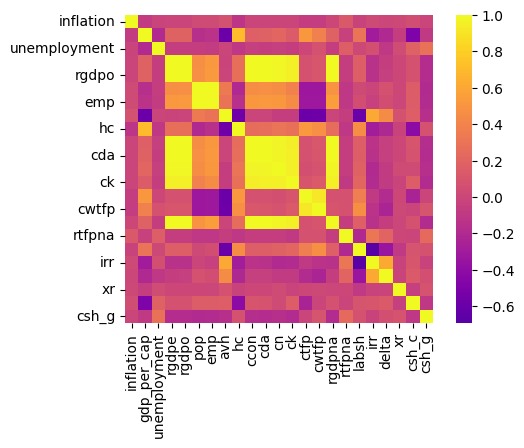

In [27]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, cmap="plasma", center=0, square=True)
plt.show()